This notebook shows some of the functionality in PyCNO.

In [1]:
# import dependencies
import numpy as np
import matplotlib.pyplot as plt
import pycno

To get started, create an instance of the Model class by giving the model_name of one of our models, or the path to another model in .sbml format.

In [2]:
model = pycno.Model(
    model_name='PSMA'
    )

Use the simulate method of the model class to simulate the model.

In [3]:
dose = pycno.Dose(
    times = [0],
    targets = {
        'Vein.Hot': [10],
        'Vein.Cold': [100]
    })

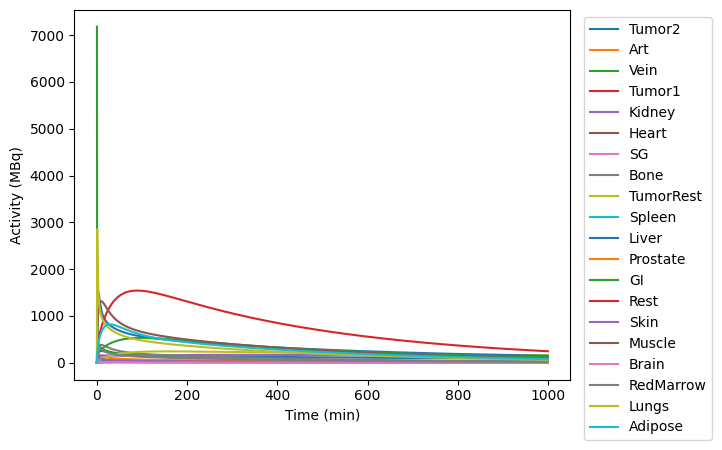

In [4]:
time, TACs = model.simulate(dose=dose, stop=1000, steps=10000)

plt.plot(time, TACs[0,:,:])
plt.ylabel('Activity (MBq)')
plt.xlabel('Time (min)')
plt.legend(model.output_compartments, loc='upper right', bbox_to_anchor=(1.3, 1))
plt.show()

By default, all compartments are returned. To specify only some compartments, the observables argument can be used:

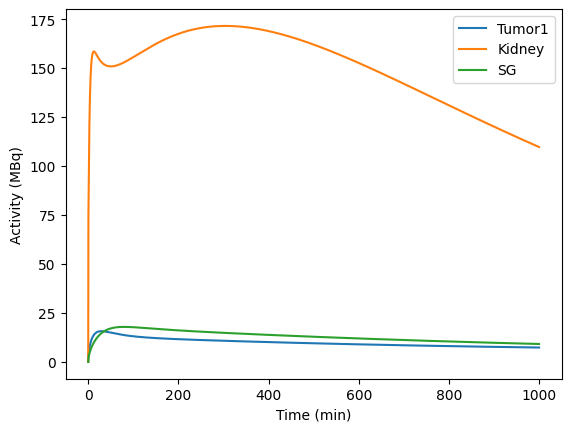

In [5]:
output_compartments = ['Tumor1', 'Kidney', 'SG']
time, TACs = model.simulate(dose=dose, stop=1000, steps=10000, output_compartments=output_compartments)

plt.plot(time, TACs[0,:,:])
plt.legend(output_compartments)
plt.ylabel('Activity (MBq)')
plt.xlabel('Time (min)')
plt.show()

To list the compartments in the model:

In [6]:
print(model.get_compartments())

['Tumor2', 'Art', 'Vein', 'Tumor1', 'Kidney', 'Heart', 'SG', 'Bone', 'TumorRest', 'Spleen', 'Liver', 'Prostate', 'GI', 'Rest', 'Skin', 'Muscle', 'Brain', 'RedMarrow', 'Lungs', 'Adipose']


There are also subcompartments contained inside compartments. To list these:

In [7]:
print(model.get_subcompartments())

['Tumor2Vas', 'Tumor2Int', 'Tumor2Bound', 'Tumor2Intern', 'Tumor1Vas', 'Tumor1Int', 'Tumor1Bound', 'Tumor1Intern', 'KidneyVas', 'KidneyInt', 'KidneyBound', 'KidneyIntern', 'HeartVas', 'HeartInt', 'SGVas', 'SGInt', 'SGBound', 'SGIntern', 'BoneVas', 'BoneInt', 'TumorRestVas', 'TumorRestInt', 'TumorRestBound', 'TumorRestIntern', 'SpleenVas', 'SpleenInt', 'SpleenBound', 'SpleenIntern', 'LiverVas', 'LiverInt', 'LiverBound', 'LiverIntern', 'ProstateVas', 'ProstateInt', 'ProstateBound', 'ProstateIntern', 'GIVas', 'GIInt', 'GIBound', 'GIIntern', 'RestVas', 'RestInt', 'SkinVas', 'SkinInt', 'MuscleVas', 'MuscleInt', 'BrainVas', 'BrainInt', 'RedMarrowVas', 'RedMarrowInt', 'LungsVas', 'LungsInt', 'AdiposeVas', 'AdiposeInt', 'KidneyIntera']


By default, these are not retuned. They can be specified as observables, or optionally all returned using the return_subcompartments argument.

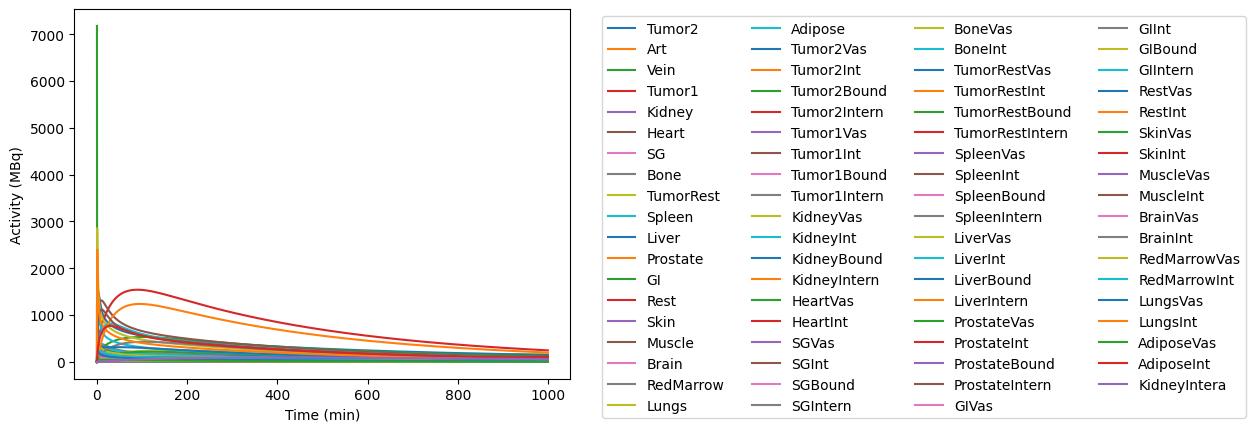

In [8]:
time, TACs = model.simulate(dose=dose, stop=1000, steps=10000, return_all_subcompartments=True)

plt.plot(time, TACs[0,:,:])
plt.legend(model.output_compartments, bbox_to_anchor=(1.05, 1), ncols=4)
plt.ylabel('Activity (MBq)')
plt.xlabel('Time (min)')
plt.show()

You can return addition of mutiple compartments:

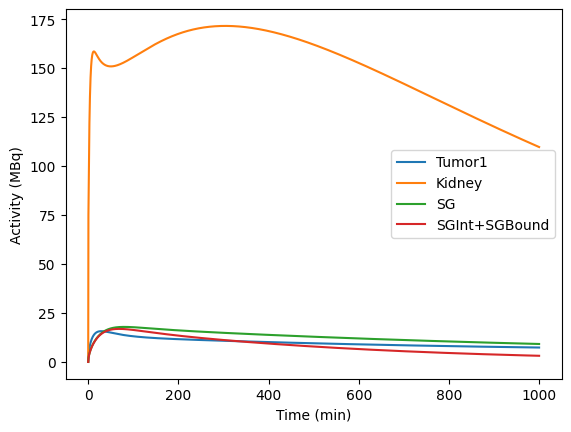

In [9]:
output_compartments = ['Tumor1', 'Kidney', 'SG', 'SGInt+SGBound']
time, TACs = model.simulate(dose=dose, stop=1000, steps=10000, output_compartments=output_compartments)

plt.plot(time, TACs[0,:,:])
plt.legend(output_compartments)
plt.ylabel('Activity (MBq)')
plt.xlabel('Time (min)')
plt.show()

To change parameters in model:

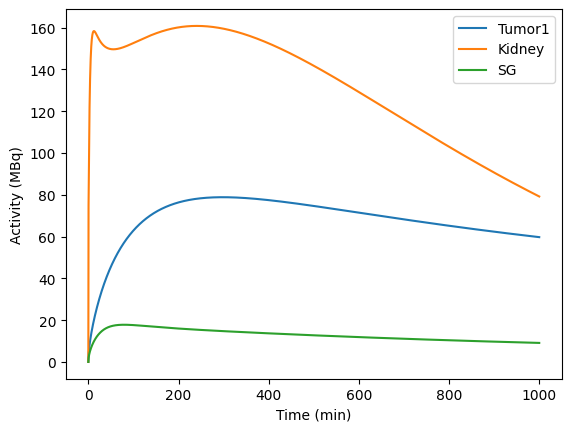

In [10]:
parameters = {
    'Rden_Tumor1': 500,
    'lambdaRel_Kidney': 0.005
}

model = pycno.Model(
    model_name='PSMA',
    parameters=parameters
    )

dose = pycno.Dose(
    times = [0],
    targets = {
        'Vein.Hot': [10],
        'Vein.Cold': [100]
    })

output_compartments = ['Tumor1', 'Kidney', 'SG']
time, TACs = model.simulate(dose=dose, stop=1000, steps=10000, output_compartments=output_compartments)

plt.plot(time, TACs[0,:,:])
plt.legend(output_compartments)
plt.ylabel('Activity (MBq)')
plt.xlabel('Time (min)')
plt.show()

To list parameters in the model:

In [11]:
print(model.get_parameters())

[('lambdaPhys', 7.15e-05), ('k_on_toAlb', 0.0), ('k_off_toAlb', 0.0), ('k_on', 0.046), ('k_off', 0.368), ('F_Tumor1', -1.0), ('PSAlb_Tumor1', -1.0), ('PS_Tumor1', -1.0), ('Rden_Tumor1', 500.0), ('R0_Tumor1', -1.0), ('lambdaIntern_Tumor1', 0.001), ('lambdaRel_Tumor1', 0.00015), ('F_Tumor2', -1.0), ('PSAlb_Tumor2', -1.0), ('PS_Tumor2', -1.0), ('Rden_Tumor2', 19.0), ('R0_Tumor2', -1.0), ('lambdaIntern_Tumor2', 0.001), ('lambdaRel_Tumor2', 0.00015), ('F_TumorRest', -1.0), ('PSAlb_TumorRest', -1.0), ('PS_TumorRest', -1.0), ('Rden_TumorRest', 266.0), ('R0_TumorRest', 13.0), ('lambdaIntern_TumorRest', 0.001), ('lambdaRel_TumorRest', -1.0), ('F_SG', -1.0), ('PS_SG', -1.0), ('Rden_SG', 38.0), ('R0_SG', -1.0), ('lambdaIntern_SG', -1.0), ('lambdaRel_SG', 0.00042), ('F_Spleen', -1.0), ('PS_Spleen', -1.0), ('Rden_Spleen', -1.0), ('R0_Spleen', -1.0), ('lambdaIntern_Spleen', -1.0), ('lambdaRel_Spleen', -1.0), ('F_Prostate', -1.0), ('PS_Prostate', -1.0), ('Rden_Prostate', -1.0), ('R0_Prostate', -1.0),

To change compartment volumes:

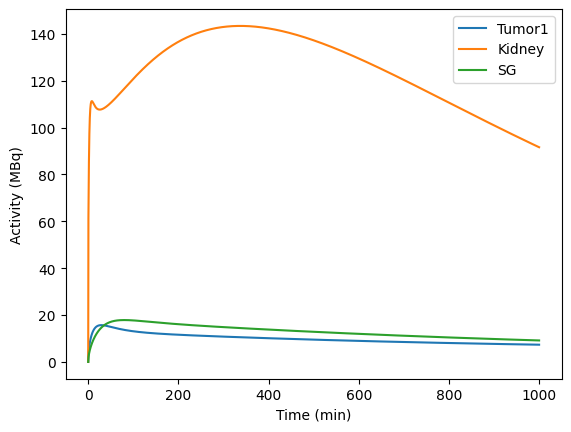

In [16]:
compartment_volumes = {
    'Kidney': 0.2,
}

model = pycno.Model(
    model_name='PSMA',
    compartment_volumes=compartment_volumes
    )

dose = pycno.Dose(
    times = [0],
    targets = {
        'Vein.Hot': [10],
        'Vein.Cold': [100]
    })

output_compartments = ['Tumor1', 'Kidney', 'SG']
time, TACs = model.simulate(dose=dose, stop=1000, steps=10000, output_compartments=output_compartments)

plt.plot(time, TACs[0,:,:])
plt.legend(output_compartments)
plt.ylabel('Activity (MBq)')
plt.xlabel('Time (min)')
plt.show()

To sweep over multiple parameter combinations:

  0%|          | 0/6 [00:00<?, ?it/s]

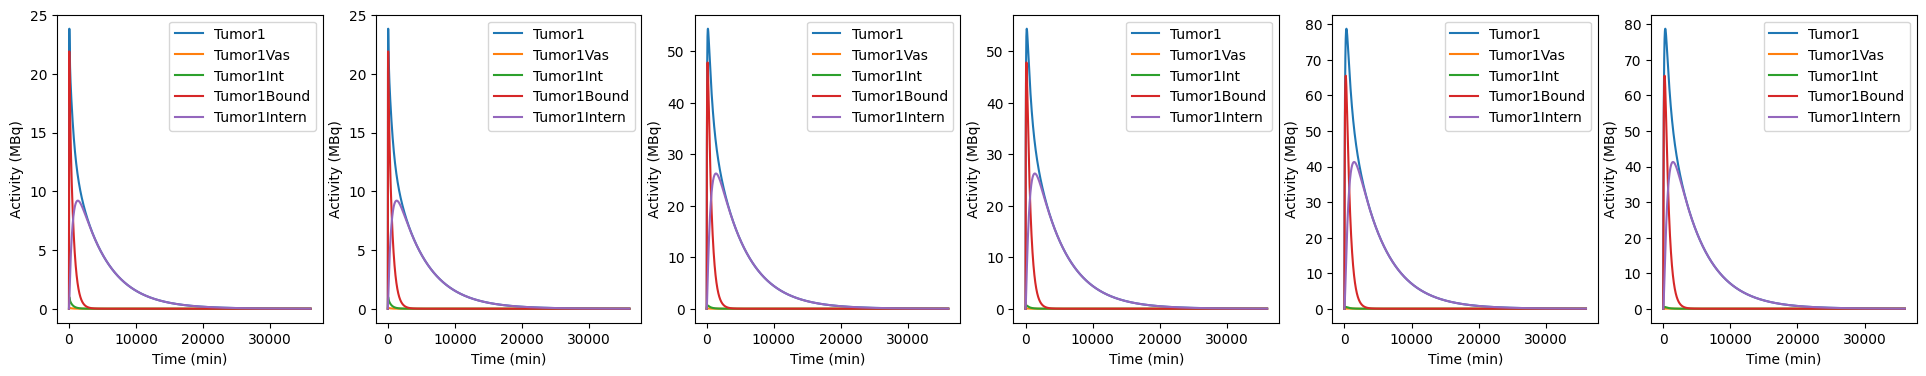

In [13]:
swept_parameters = ['Rden_Tumor1']
swept_values = [(Rden_Kidney,Rden_Tumor1)
                for Rden_Kidney in np.linspace(100, 500, 3)
                for Rden_Tumor1 in np.arange(100, 300, 100)
                ]
output_compartments = ['Tumor1', 'Tumor1Vas', 'Tumor1Int', 'Tumor1Bound', 'Tumor1Intern']

dose = pycno.Dose(
    times = [0],
    targets = {
        'Vein.Hot': [10],
        'Vein.Cold': [100]
    })

time, TACs = model.simulate(dose=dose, stop=25*24*60, steps=int(25*24*60/5), output_compartments=output_compartments, swept_parameters=swept_parameters, swept_values=swept_values)

fig = plt.figure(figsize=(len(swept_values)*4,4))
for idx in range(TACs.shape[0]):
    fig.add_subplot(1,len(swept_values),idx+1)
    plt.plot(time, TACs[idx,:,:])
    plt.legend(output_compartments)
    plt.ylabel('Activity (MBq)')
    plt.xlabel('Time (min)')
plt.show()